# Make All Figures for Main Manuscript

Kendra Wyant  
July 2, 2024

In [ ]:

suppressPackageStartupMessages(library(tidyverse))
suppressPackageStartupMessages(source("https://github.com/jjcurtin/lab_support/blob/main/format_path.R?raw=true"))
suppressPackageStartupMessages(library(tidyposterior))
library(kableExtra, exclude = "group_rows")
library(patchwork)

theme_set(theme_classic())

path_models_lag <- format_path(str_c("studydata/risk/models/lag"))
path_shared <- format_path("studydata/risk/data_processed/shared")
path_processed <- format_path("studydata/risk/data_processed/lag")


Data for figures

In [ ]:
test_metrics_all_pp_perf <- read_csv(here::here(path_models_lag,
                                                "test_metrics_all_pp_perf.csv"),
                                     show_col_types = FALSE)

pp_dem_contrast <- read_csv(here::here(path_models_lag, "pp_dem_contrast_all.csv"),
                            show_col_types = FALSE)


## Figure 1: Posterior probability for auROC by model

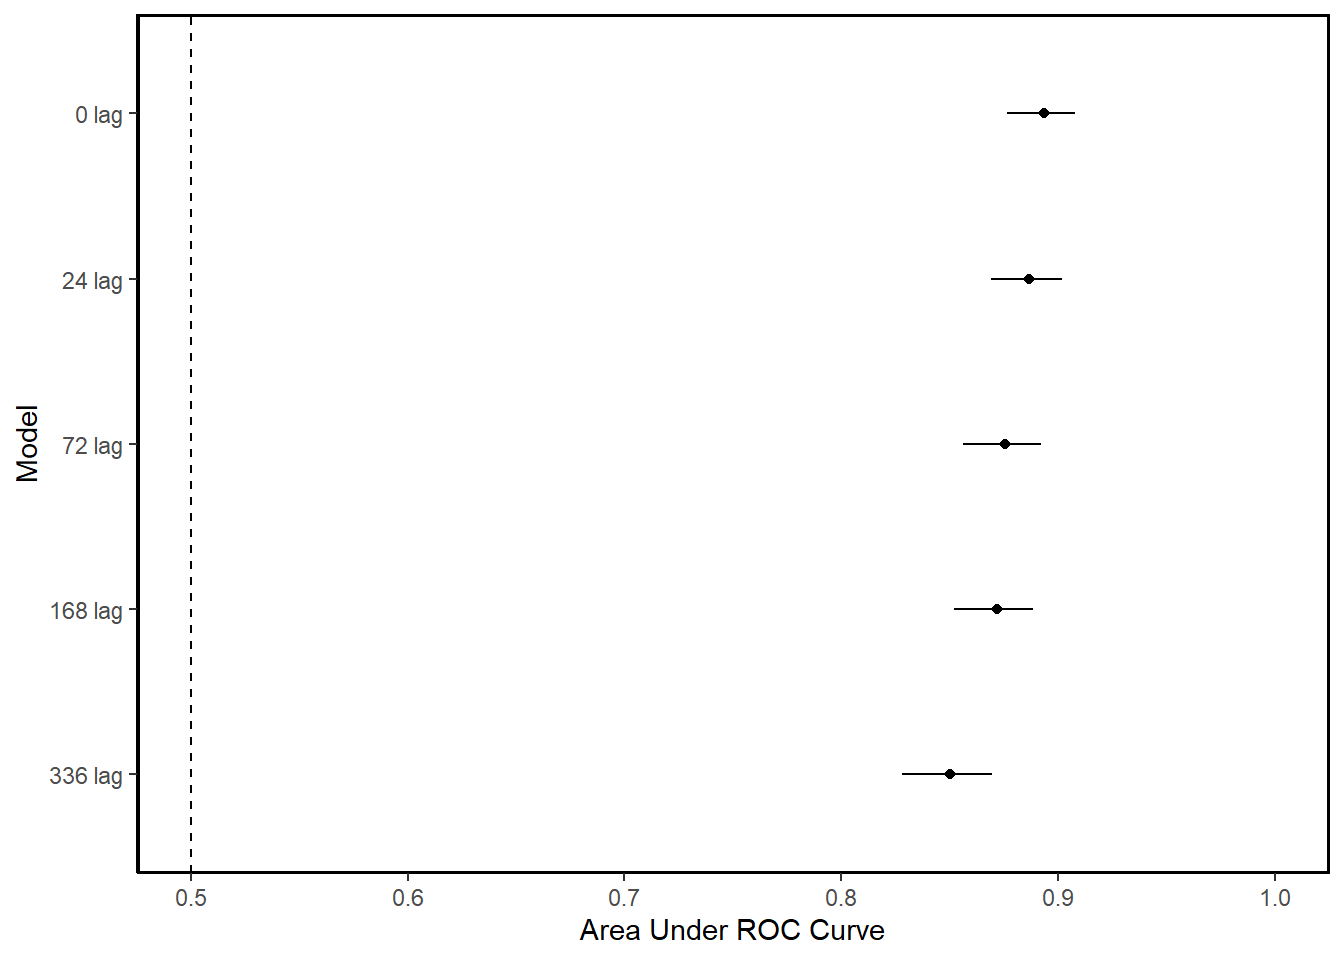

In [ ]:

test_metrics_all_pp_perf |>
  mutate(model = factor(model, levels = c("336 lag", "168 lag", "72 lag", "24 lag", "0 lag" ))) |> 
  ggplot() + 
  geom_point(aes(x = pp_median, y = model), color = "black") +
  geom_segment(mapping = aes(y = model, x = pp_lower, xend = pp_upper),
                data = test_metrics_all_pp_perf) +
  scale_x_continuous("Area Under ROC Curve", limits = c(.50, 1.0)) +
  ylab("Model") +
  theme_classic() +
  theme(legend.position = "none",
        panel.border = element_rect(colour = "black", fill = NA, linewidth = 1)) +
  geom_vline(xintercept = 0.5, linetype = "dashed", color = "black")


## Figure 2: auROC differences by demographic group

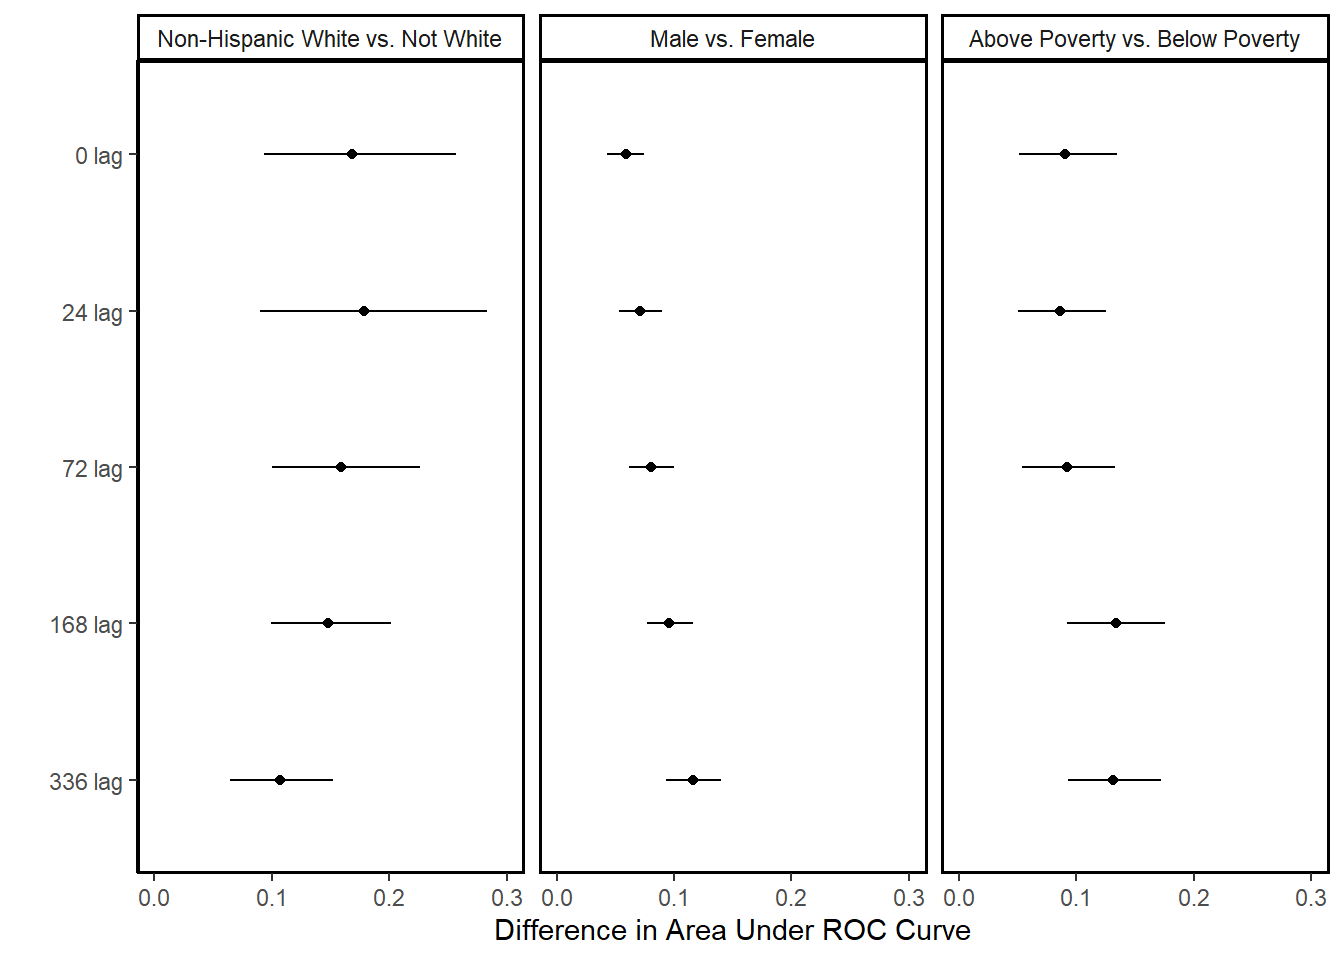

In [ ]:

pp_dem_contrast |>
  mutate(lag = factor(lag, 
                      levels = c(336, 168, 72, 24, 0),
                      labels = c("336 lag", "168 lag", "72 lag", "24 lag", "0 lag" )),
         contrast = factor(contrast, levels = c("non-hispanic white vs not white",
                                                "male vs female",
                                                "above poverty vs below poverty"),
                           labels = c("Non-Hispanic White vs. Not White",
                                                "Male vs. Female",
                                                "Above Poverty vs. Below Poverty"))) |> 
  ggplot() + 
  geom_point(aes(x = median, y = lag), color = "black") +
  geom_segment(mapping = aes(y = lag, x = lower, xend = upper),
                data = pp_dem_contrast |>
                 mutate(lag = factor(lag, 
                                     levels = c(336, 168, 72, 24, 0),
                                     labels = c("336 lag", "168 lag", "72 lag", "24 lag", "0 lag" )),
                 contrast = factor(contrast, levels = c("non-hispanic white vs not white",
                                                "male vs female",
                                                "above poverty vs below poverty"),
                                    labels = c("Non-Hispanic White vs. Not White",
                                                "Male vs. Female",
                                                "Above Poverty vs. Below Poverty")))) +
  facet_grid(~contrast) +
  scale_x_continuous("Difference in Area Under ROC Curve", limits = c(0, .3), breaks = c(0, .1, .2, .3)) +
  ylab("") +
  theme_classic() +
  theme(legend.position = "none",
        panel.border = element_rect(colour = "black", fill = NA, linewidth = 1)) 


## Figure 3: Shapley values

Read in data

In [ ]:
global_all <- read_rds(here::here(path_models_lag, "shap_global_all.rds")) |> 
   filter(!variable_grp %in% c("day of week (other)", "time of day (other)")) |> 
   mutate(variable_grp = reorder(variable_grp, mean_value, sum),
          model = factor(model, c("0 lag", "24 lag", "72 lag", "168 lag", "336 lag")))

shap_levels <- global_all |>
  mutate(variable_grp = reorder(variable_grp, mean_value, sum)) |>
  pull(variable_grp) |>
  levels()

local_0 <- read_rds(here::here(path_models_lag, 
                        "outer_shapsgrp_1week_0_v1_nested_main_downsized.rds")) |> 
   mutate(variable_grp = factor(variable_grp, levels = shap_levels)) |>
   filter(!variable_grp %in% c("day of week (other)", "time of day (other)"))
local_24 <- read_rds(here::here(path_models_lag,
                      "outer_shapsgrp_1week_24_v1_nested_main_downsized.rds")) |> 
   mutate(variable_grp = factor(variable_grp, levels = shap_levels)) |>
   filter(!variable_grp %in% c("day of week (other)", "time of day (other)"))
local_72 <- read_rds(here::here(path_models_lag, 
                        "outer_shapsgrp_1week_72_v1_nested_main_downsized.rds")) |>      mutate(variable_grp = factor(variable_grp, levels = shap_levels)) |>
   filter(!variable_grp %in% c("day of week (other)", "time of day (other)"))
local_168 <- read_rds(here::here(path_models_lag, 
                        "outer_shapsgrp_1week_168_v1_nested_main_downsized.rds")) |> 
   mutate(variable_grp = factor(variable_grp, levels = shap_levels)) |>
   filter(!variable_grp %in% c("day of week (other)", "time of day (other)")) 
local_336 <- read_rds(here::here(path_models_lag, 
                          "outer_shapsgrp_1week_336_v1_nested_main_downsized.rds")) |>
   mutate(variable_grp = factor(variable_grp, levels = shap_levels)) |>
   filter(!variable_grp %in% c("day of week (other)", "time of day (other)")) 


Global shapley pannel

In [ ]:
color_codes <- c("#240e31","#cb6bce", "#458892", "#75f3d3", "#751c6d")

panel_shap_global <- global_all |>
  ggplot() +
  geom_bar(aes(x = variable_grp, y = mean_value, fill = model), stat = "identity") +
  ylab("Mean(|Shapley Value|)") +
  xlab("") +
  scale_color_manual(values = color_codes) +
  scale_fill_manual(values = color_codes) +
  theme(axis.text = element_text(size = 9.5)) +
  coord_flip()


Local shapley pannels

In [ ]:
panel_shap_local_0 <- local_0 |>
  ggplot(mapping = aes(x = variable_grp, y = value)) +
  ggforce::geom_sina(method = "counts", maxwidth = 0.7, alpha = 0.4,
                     color = color_codes[1]) +
  geom_hline(yintercept = 0) +
  scale_y_continuous(limits = c(-2, 5), breaks = seq(-2, 5)) +
  ylab("Shapley Value") +
  xlab("") +
  theme(axis.text.y = element_blank(),
        axis.ticks.y = element_blank(),
        axis.line.y = element_blank()) +
  coord_flip()

panel_shap_local_24 <- local_24 |>
  ggplot(mapping = aes(x = variable_grp, y = value)) +
  ggforce::geom_sina(method = "counts", maxwidth = 0.7, alpha = 0.4, 
                     color = color_codes[2]) +
  geom_hline(yintercept = 0) +
  scale_y_continuous(limits = c(-2, 5), breaks = seq(-2, 5)) +
  ylab("Shapley Value") +
  xlab("") +
  theme(axis.text.y = element_blank(),
        axis.ticks.y = element_blank(),
        axis.line.y = element_blank()) +
  coord_flip()

panel_shap_local_72 <- local_72 |>
  ggplot(mapping = aes(x = variable_grp, y = value)) +
  ggforce::geom_sina(method = "counts", maxwidth = 0.7, alpha = 0.4,
                     color = color_codes[3]) +
  geom_hline(yintercept = 0) +
  scale_y_continuous(limits = c(-2, 5), breaks = seq(-2, 5)) +
  ylab("Shapley Value") +
  xlab("") +
  theme(axis.text = element_text(size = 9.5)) +
  coord_flip()

panel_shap_local_168 <- local_168 |>
  ggplot(mapping = aes(x = variable_grp, y = value)) +
  ggforce::geom_sina(method = "counts", maxwidth = 0.7, alpha = 0.4,
                     color = color_codes[4]) +
  geom_hline(yintercept = 0) +
  scale_y_continuous(limits = c(-2, 5), breaks = seq(-2, 5)) +
  ylab("Shapley Value") +
  xlab("") +
  theme(axis.text.y = element_blank(),
        axis.ticks.y = element_blank(),
        axis.line.y = element_blank()) +
  coord_flip()

panel_shap_local_336 <- local_336 |>
  ggplot(mapping = aes(x = variable_grp, y = value)) +
  ggforce::geom_sina(method = "counts", maxwidth = 0.7, alpha = 0.4,
                     color = color_codes[5]) +
  geom_hline(yintercept = 0) +
  scale_y_continuous(limits = c(-2, 5), breaks = seq(-2, 5)) +
  ylab("Shapley Value") +
  xlab("") +
  theme(axis.text.y = element_blank(),
        axis.ticks.y = element_blank(),
        axis.line.y = element_blank()) +
  coord_flip()


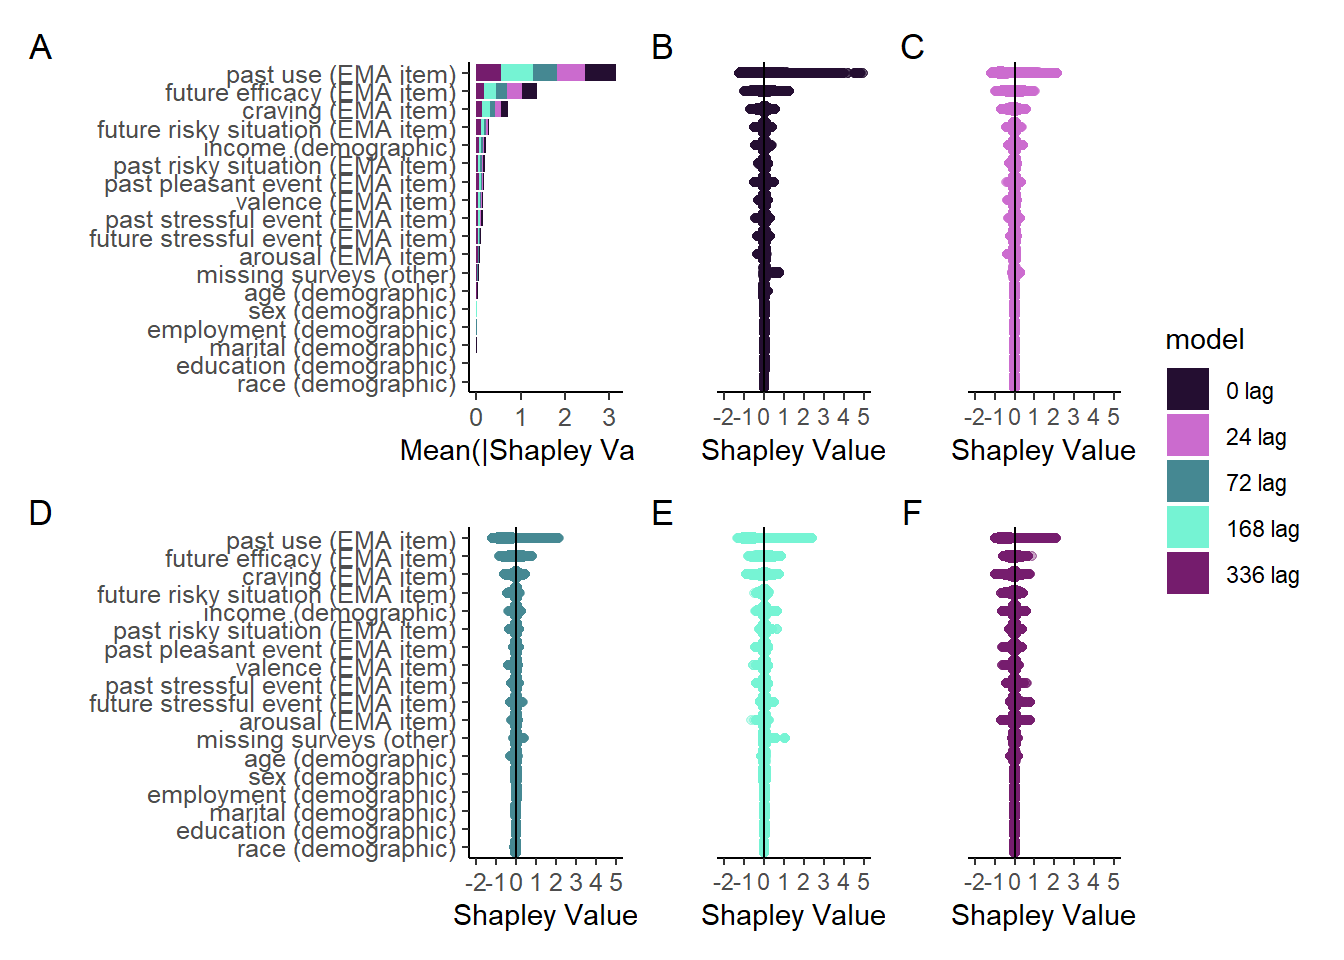

In [ ]:

panel_shap_global + panel_shap_local_0 + panel_shap_local_24 + 
  panel_shap_local_72 + panel_shap_local_168 + panel_shap_local_336 +
  plot_annotation(tag_levels = 'A') +
  plot_layout (ncol = 3, guides = "collect", width = c(1,1))

# knitr::include_graphics(path = "figures/fig_shap.jpeg")
